In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,RocCurveDisplay
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings('ignore')

In [61]:
df = pd.read_csv("../data/processed/telco_cleaned.csv")

In [62]:
df.shape

(7043, 30)

In [63]:
target = "Churn Label"

df[target].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [64]:
y = df[target].map({
    "No": 0,
    "Yes": 1
})

In [65]:
y.value_counts()

Churn Label
0    5174
1    1869
Name: count, dtype: int64

In [66]:
drop_cols = [
    "CustomerID",
    "Churn Label",
    "Churn Value",
    "Churn Score",
    "Churn Reason",
    "CLTV",
    "City",
    "Lat Long",
    "Zip Code"
]

X = df.drop(columns=drop_cols)

In [67]:
X.shape

(7043, 21)

In [68]:
X.columns.tolist()

['Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges']

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [70]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)

print("\nTrain target:")
print(y_train.value_counts(normalize=True))

print("\nTest target:")
print(y_test.value_counts(normalize=True))

Train: (5634, 21)
Test: (1409, 21)

Train target:
Churn Label
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Test target:
Churn Label
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [71]:
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=["number"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges']

Categorical features:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [72]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",StandardScaler(),numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore" ),
            categorical_features
        )
    ]
)

In [73]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier",LogisticRegression(max_iter=1000,random_state=42,class_weight='balanced' ))
    ]
)

In [74]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['Latitude','Longitude','Gender',...,'Payment Method','Monthly Charges', 'Total Charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [75]:
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [76]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.7437899219304471
Precision: 0.51138353765324
Recall   : 0.7807486631016043
F1 Score : 0.617989417989418
ROC-AUC  : 0.8480766746751401


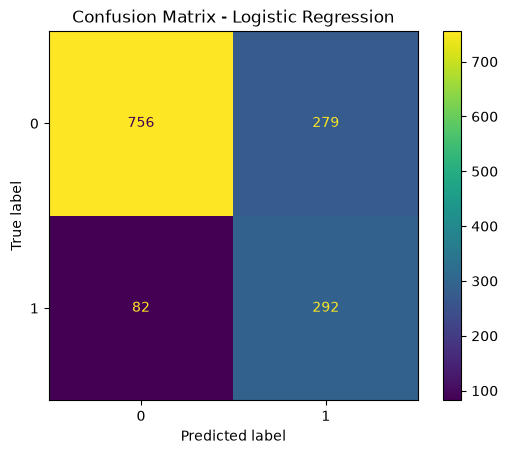

In [77]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [78]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



In [80]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

In [81]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['Latitude','Longitude','Gender',...,'Payment Method','Monthly Charges', 'Total Charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [83]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

In [84]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.7757274662881476
Precision: 0.5653153153153153
Recall   : 0.6711229946524064
F1 Score : 0.6136919315403423
ROC-AUC  : 0.8422498643726265

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1035
           1       0.57      0.67      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [89]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

print("Negative class (0):", negative)
print("Positive class (1):", positive)

Negative class (0): 4139
Positive class (1): 1495


In [90]:
scale_pos_weight = negative / positive

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 2.768561872909699


In [91]:
xg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                random_state=42,
                eval_metric="logloss",
                n_jobs=-1
            )
        )
    ]
)

In [92]:
xg_model.fit(X_train, y_train)

y_pred = xg_model.predict(X_test)
y_prob = xg_model.predict_proba(X_test)[:, 1]

In [93]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.7565649396735273
Precision: 0.5284403669724771
Recall   : 0.7700534759358288
F1 Score : 0.6267682263329706
ROC-AUC  : 0.8486321010617686

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



In [94]:
def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

In [96]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "XGBoost": xg_model
}


results_list = []
for name, model in models.items():
    results_list.append(evaluate_model(name, model, X_test, y_test))

comparison_df = pd.DataFrame(results_list)
comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7438,0.5114,0.7807,0.6180,0.8481
1,Random Forest,0.7757,0.5653,0.6711,0.6137,0.8422
2,XGBoost,0.7566,0.5284,0.7701,0.6268,0.8486


In [ ]:
#XGBoost was selected as the final classification model
#because it achieved the highest F1-score and ROC-AUC while maintaining a high recall for churned customers.

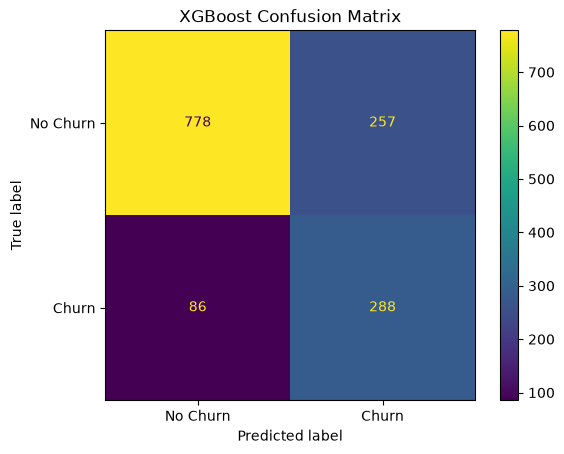

In [101]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

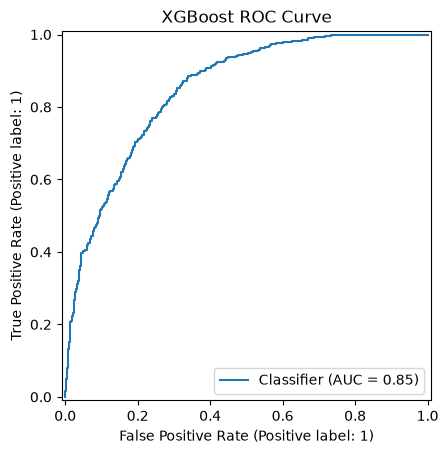

In [103]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("XGBoost ROC Curve")
plt.show()

In [105]:
feature_names = xg_model.named_steps["preprocessor"].get_feature_names_out()

importances = xg_model.named_steps["classifier"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
39,cat__Contract_Month-to-month,0.234046
21,cat__Online Security_No,0.107972
19,cat__Internet Service_Fiber optic,0.077511
41,cat__Contract_Two year,0.076856
12,cat__Dependents_Yes,0.050865
11,cat__Dependents_No,0.038292
30,cat__Tech Support_No,0.035879
46,cat__Payment Method_Electronic check,0.026107
18,cat__Internet Service_DSL,0.025985
40,cat__Contract_One year,0.025632


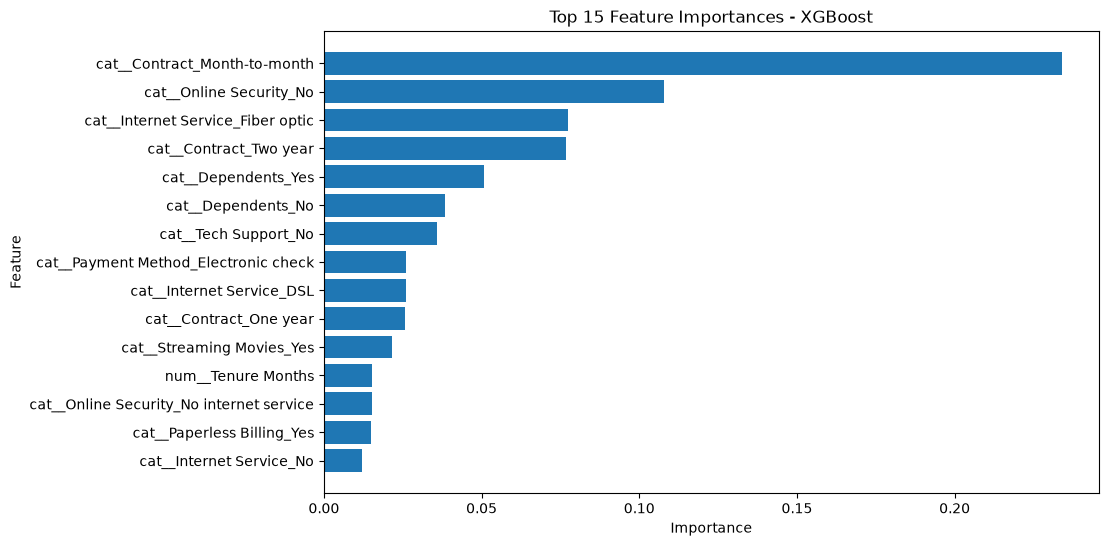

In [106]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"].head(15)[::-1],
    feature_importance["Importance"].head(15)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - XGBoost")
plt.show()

In [107]:
# import joblib

# joblib.dump(
#     xg_model,
#     "../models/xgboost_churn_model.pkl"
# )

['../models/xgboost_churn_model.pkl']

In [108]:
# joblib.dump(
#     X.columns.tolist(),
#     "../models/churn_features.pkl"
# )

['../models/churn_features.pkl']

# Classification Conclusion

Three classification models were evaluated: Logistic Regression, Random Forest, and XGBoost.

XGBoost was selected as the final model based on its overall performance, achieving the highest F1-score and ROC-AUC while maintaining a high recall for churned customers.

The final XGBoost model was saved for later use in the Streamlit application.